# 4. Performance Tracking

This chapter measures how the portfolio is actually doing — not in theory,
but against the real trade ledger from InvestEngine. Results are reported
across three overlapping time windows so you can see both the full picture
and the current tax-year in isolation:

| Tenor | Window | What it tells you |
|---|---|---|
| **Overall** | First trade (12 May 2025) → today | Total investor experience since inception |
| **FY25** | 5 Apr 2025 → 4 Apr 2026 | Complete UK tax year 2025-26 |
| **FY26** | 5 Apr 2026 → today | Current tax year, in-flight |

Two return metrics are reported for each tenor:

- **[TWR](../content/99_glossary.md#return-metrics)** (Time-Weighted Return) — measures the
  *strategy*, independent of when cash was deposited. This is the number to
  compare against a benchmark.
- **[MWR](../content/99_glossary.md#future-metrics-not-yet-in-the-book)** (Money-Weighted Return)
  — measures the *investor experience*, including the timing of contributions.
  This is what your actual wealth has grown by.

```{admonition} Why these two returns can differ
:class: note

If you deposited your full £20,000 just before a market dip, your MWR will
lag your TWR because more capital was at risk during the drawdown. If you
happened to invest before a rally, MWR leads. TWR strips that timing luck
out entirely, which is why it is the standard for comparing strategies.
```

Cash deposits: £20,000 in FY25 (InvestEngine) · £20,000 in FY26 (£19,000 IE +
£1,000 Trading212) · £40,000 total. The Trading212 portion is excluded from
TWR and [Sharpe](../content/99_glossary.md#risk-metrics) figures because those trade
confirmations are unavailable, but the four T212 positions are included in
the holdings snapshot as estimated values.

In [7]:
from pathlib import Path
import sys
sys.path.insert(0, str(Path("..").resolve()))

from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from etf_utils.config import RISK_FREE_RATE, PROJECT_ROOT
from etf_utils.data_provider import DataProvider
from etf_utils.database import (
    load_portfolio,
    save_rebalancing_trades,
)
from etf_utils.backtesting import (
    Backtester,
    combine_investengine_statements,
    rebase_cumret,
)
from etf_utils.metrics import (
    calculate_beta,
    calculate_information_ratio,
    calculate_max_drawdown,
    calculate_sharpe_ratio,
    calculate_tracking_error,
    rolling_volatility_from_cumret,
)

FIRST_TRADE_DATE = pd.Timestamp("2025-05-12")
FY25_START, FY25_END = pd.Timestamp("2025-04-05"), pd.Timestamp("2026-04-04")
FY26_START = pd.Timestamp("2026-04-05")
TODAY      = pd.Timestamp.now().normalize()

TENORS = {
    "Overall": (FIRST_TRADE_DATE, TODAY),
    "FY25":    (FY25_START, FY25_END),
    "FY26":    (FY26_START, TODAY),
}
TENOR_COLOURS = {"Overall": "#0f172a", "FY25": "#3b82f6", "FY26": "#10b981"}

DEPOSITS_IE = {"Overall": 38_200.0, "FY25": 20_000.0, "FY26": 18_200.0}

# Trading212 portion of the FY26 deposit — not in any IE statement, so treat as
# a synthetic equal-split buy at the 13-Apr-2026 close. Used only in the final
# holdings snapshot; excluded from all TWR / MWR / Sharpe metrics.
# T212 total = £1,800 split across 4 ETFs = £450 each.
T212_DEPOSIT_DATE = pd.Timestamp("2026-04-13")
T212_TICKERS = ["SLVP", "AIGA", "CRUD", "COPA"]
T212_DEPOSIT_EACH = 450.0  # £1,800 / 4

provider = DataProvider()
portfolio_26 = load_portfolio(year=2026)
portfolio_25 = load_portfolio(year=2025)
print(f"Loaded 2026 portfolio: {len(portfolio_26)} positions, "
      f"{portfolio_26['asset_class'].nunique()} asset classes.")
print(f"Loaded 2025 portfolio: {len(portfolio_25)} positions "
      f"(used for FY25 benchmark).")
for name, (s, e) in TENORS.items():
    print(f"  {name:8s}  {s.date()} → {e.date()}   deposits = £{DEPOSITS_IE[name]:,.0f}")

Loaded 2026 portfolio: 20 positions, 4 asset classes.
Loaded 2025 portfolio: 16 positions (used for FY25 benchmark).
  Overall   2025-05-12 → 2026-04-26   deposits = £38,200
  FY25      2025-04-05 → 2026-04-04   deposits = £20,000
  FY26      2026-04-05 → 2026-04-26   deposits = £18,200


## 1. Trade ledger

All return calculations are driven by the actual InvestEngine trading
statements. Each statement is a CSV export of buy/sell activity; they are
combined, deduplicated, and persisted to the database so the rest of this
notebook can rerun at any time to pick up new trades.

Trading212 trades are **not** included — the T212 statement export is
unavailable. Those four positions (WSIL, AIGA, AIGE, COPA) appear only in
the holdings snapshot as estimates.

In [8]:
stmt_dir = PROJECT_ROOT / "data" / "investment_statements"
trades = combine_investengine_statements(
    stmt_dir / "RebalancingTrades2025.csv",
    stmt_dir / "RebalancingTrades2026.csv",
)
save_rebalancing_trades(trades, portfolio_year=2026)

print(f"Parsed {len(trades)} combined trades and saved to DB.")
print(f"Date range: {trades['trade_date'].min().date()} \u2192 "
      f"{trades['trade_date'].max().date()}")
print(f"Tickers: {trades['ticker'].nunique()}")


Parsed 64 combined trades and saved to DB.
Date range: 2026-04-09 → 2026-04-21
Tickers: 22


## 2. Headline summary

Top-line numbers for each tenor — one row per window.

- **Base Rate** — the exact cash-yield opportunity cost for that tenor,
  calculated by geometrically compounding daily SONIA (Sterling Overnight
  Index Average) rates. A [Sharpe](../content/99_glossary.md#risk-metrics) above zero
  means the portfolio beat the risk-free cash rate on a volatility-adjusted
  basis; a negative Sharpe means cash would have served you better.
- **Ann. Vol** — annualised daily-return volatility of the rebased
  [TWR](../content/99_glossary.md#return-metrics) curve. Lower is smoother.

In [9]:
# Backtester and master TWR series are built here because the summary is the
# first narrative section; the later curve / vol / pro-metrics cells reuse
# these variables without rebuilding.
bt = Backtester.from_trades(trades, provider, end_date=TODAY)
master_twr = bt.run_twr_series(trades)

from etf_utils.metrics import calculate_dynamic_rfr
try:
    sonia_df = provider.get_historical_prices("FRED:IUDSOIA", start_date=FIRST_TRADE_DATE, end_date=TODAY)
    sonia_series = sonia_df["close"]
except Exception as e:
    print(f"Warning: Could not fetch FRED SONIA rate: {e}")
    sonia_series = pd.Series(index=pd.DatetimeIndex([]), dtype=float)

rows = []
for name, (s, e) in TENORS.items():
    ledger = trades[trades["trade_date"] <= e].groupby("ticker")["signed_qty"].sum()
    end_val = 0.0
    for t, sh in ledger.items():
        if sh <= 0:
            continue
        px = bt.get_price(t, e)
        if px:
            end_val += sh * px
    cash = DEPOSITS_IE[name]
    twr_series_tenor = rebase_cumret(master_twr.loc[:e], s)
    twr = twr_series_tenor.iloc[-1] if not twr_series_tenor.empty else float("nan")
    mwr = (end_val / cash - 1) * 100 if cash > 0 else float("nan")
    dynamic_rfr = float("nan")

    if len(twr_series_tenor) >= 5:
        daily_ret = (1 + twr_series_tenor / 100).pct_change().dropna()
        ann_vol = float(daily_ret.std() * np.sqrt(252) * 100)
        n_days = (twr_series_tenor.index[-1] - twr_series_tenor.index[0]).days
        ann_ret = ((1 + twr / 100) ** (365 / n_days) - 1) * 100 if n_days > 0 else float("nan")
        
        # Calculate bespoke cash yield for the tenor
        dynamic_rfr = calculate_dynamic_rfr(sonia_series, s, e)
        # If unavailable, fallback to config RISK_FREE_RATE (represented as decimal, so * 100 to match ann_ret percentage)
        rfr_pct = dynamic_rfr if not pd.isna(dynamic_rfr) else (RISK_FREE_RATE * 100)
        
        # Convert all to decimals to avoid unit mismatches before calling calculate_sharpe_ratio
        sharpe = calculate_sharpe_ratio(ann_ret / 100.0, ann_vol / 100.0, risk_free_rate=rfr_pct / 100.0)
    else:
        ann_vol = sharpe = dynamic_rfr = float("nan")

    rows.append({
        "start": s.date(),
        "end": e.date(),
        "days": (e - s).days,
        "base_rate": round(dynamic_rfr, 2) if not pd.isna(dynamic_rfr) else "N/A", 
        "cash_deposited": cash,
        "ending_value": round(end_val, 2),
        "twr_pct": round(twr, 2),
        "mwr_pct": round(mwr, 2),
        "ann_vol_pct": round(ann_vol, 2),
        "sharpe": round(sharpe, 2),
    })

summary_df = pd.DataFrame(rows, index=list(TENORS))


def _colour_neg(val):
    if pd.isna(val):
        return ""
    return "color: #dc2626; font-weight: bold" if val < 0 else ""


display_df = summary_df[[
    "cash_deposited", "ending_value", "twr_pct", "mwr_pct", "ann_vol_pct", "sharpe"
]].rename(columns={
    "cash_deposited": "Cash In (£)",
    "ending_value": "Value (£)",
    "twr_pct": "TWR (%)",
    "mwr_pct": "MWR (%)",
    "ann_vol_pct": "Ann. Vol (%)",
    "sharpe": "Sharpe",
})
styled = (display_df.style
    .format({
        "Cash In (£)": "£{:,.0f}",
        "Value (£)": "£{:,.2f}",
        "TWR (%)": "{:+.2f}%",
        "MWR (%)": "{:+.2f}%",
        "Ann. Vol (%)": "{:.2f}%",
        "Sharpe": "{:+.2f}",
    })
    .map(_colour_neg, subset=["TWR (%)", "MWR (%)", "Sharpe"])
    .set_caption("Portfolio performance by tenor (IE-only; T212 £1,800 excluded)"))
display(styled)

Loading FRED:IUDSOIA from local FRED cache: data\intermediate\fred_cache_IUDSOIA.csv


,Cash In (£),Value (£),TWR (%),MWR (%),Ann. Vol (%),Sharpe
Overall,"£38,200","£16,174.46",-6.83%,-57.66%,31.80%,-2.71
FY25,"£20,000",£0.00,+nan%,-100.00%,nan%,+nan
FY26,"£18,200","£16,174.46",-6.83%,-11.13%,31.80%,-2.71


## 3. Daily return curve

The [TWR](../content/99_glossary.md#return-metrics) series rebased to 0% at the start of
each tenor, so the three lines are directly comparable. Each line answers:
*"how has £1 invested at the start of this window grown?"* Vertical markers
show every rebalance date from the InvestEngine ledger.

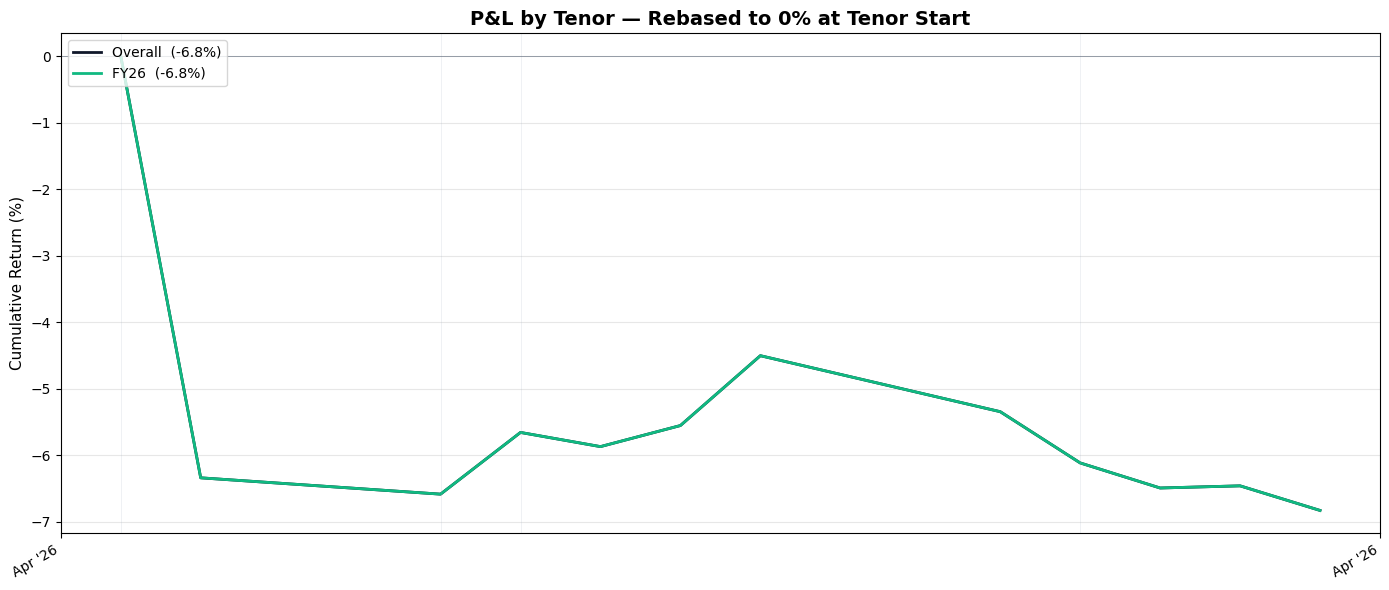

Tenor-final TWR (rebased):
  Overall     -6.83%
  FY26        -6.83%


In [10]:
fig, ax = plt.subplots(figsize=(14, 6))
for name, (s, e) in TENORS.items():
    series = rebase_cumret(master_twr.loc[:e], s)
    if series.empty:
        continue
    ax.plot(series.index, series, color=TENOR_COLOURS[name],
            linewidth=2.0, label=f"{name}  ({series.iloc[-1]:+.1f}%)")

rb_dates = [d for d in sorted(pd.to_datetime(trades["trade_date"]).unique())
            if FIRST_TRADE_DATE <= pd.Timestamp(d) <= TODAY]
for rd in rb_dates:
    ax.axvline(rd, color="#94a3b8", alpha=0.15, linewidth=0.7)

ax.axhline(0, color="#475569", linewidth=0.6, alpha=0.6)
ax.set_title("P&L by Tenor — Rebased to 0% at Tenor Start",
             fontsize=14, fontweight="bold")
ax.set_ylabel("Cumulative Return (%)", fontsize=11)
ax.grid(axis="y", alpha=0.3)
ax.legend(loc="upper left", fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
fig.autofmt_xdate(rotation=30)
plt.tight_layout()
plt.show()

print("Tenor-final TWR (rebased):")
for name, (s, e) in TENORS.items():
    series = rebase_cumret(master_twr.loc[:e], s)
    if not series.empty:
        print(f"  {name:8s}  {series.iloc[-1]:+7.2f}%")

## 4. Rolling 30-day volatility

Annualised 30-day rolling volatility for each tenor. A rising vol line flags
a regime shift — periods where the portfolio was being buffeted harder by
daily price swings. Comparing the three tenors side-by-side makes it easy
to spot whether current conditions are unusually calm or unusually turbulent
relative to the FY25 baseline.

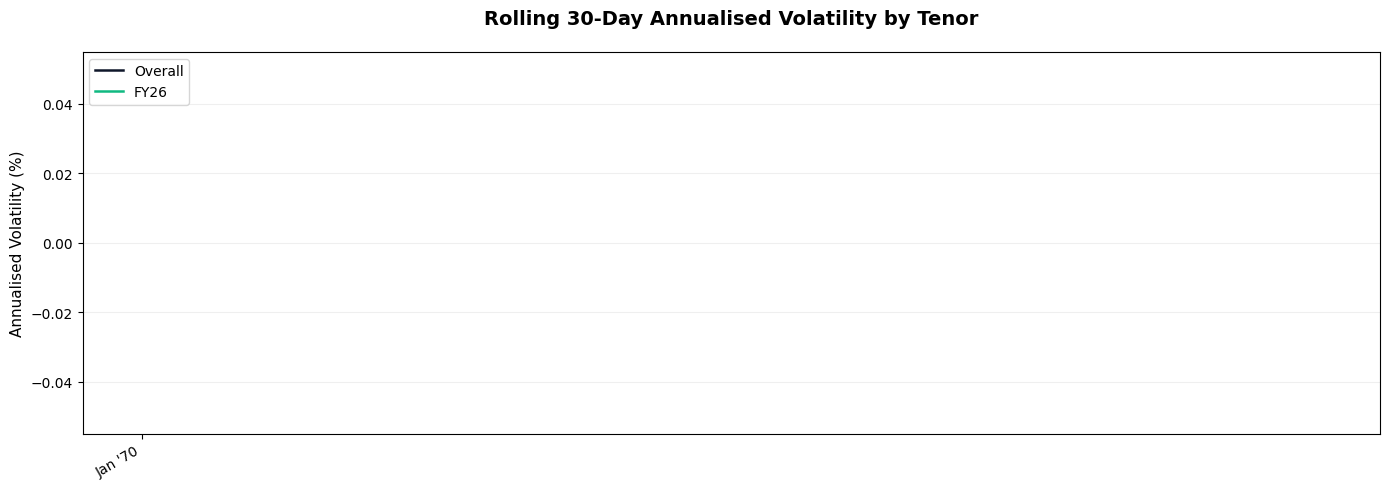

In [11]:
fig, ax = plt.subplots(figsize=(14, 5))
for name, (s, e) in TENORS.items():
    series = rebase_cumret(master_twr.loc[:e], s)
    if series.empty:
        continue
    vol = rolling_volatility_from_cumret(series, window=30)
    ax.plot(vol.index, vol, color=TENOR_COLOURS[name], linewidth=1.8, label=name)

ax.set_title("Rolling 30-Day Annualised Volatility by Tenor",
             fontsize=14, fontweight="bold", pad=20)
ax.set_ylabel("Annualised Volatility (%)", fontsize=11)
ax.grid(axis="y", alpha=0.2)
ax.legend(loc="upper left", fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
fig.autofmt_xdate(rotation=30)
plt.tight_layout()
plt.show()


## 5. Holdings snapshot

Two snapshots of the share ledger, valued at closing prices:

- **FY25 close (4 Apr 2026)** — InvestEngine positions only. Includes the
  23 Mar 2026 pre-rebalance trades, so the snapshot aligns with the FY25
  tenor end.
- **Today** — current portfolio including both IE positions and estimated
  Trading212 positions (SLVP / AIGA / CRUD / COPA; flagged in the Platform
  column as approximate).

Red highlighting marks negative [P&L](../content/99_glossary.md#return-metrics) or
[MWR](../content/99_glossary.md#future-metrics-not-yet-in-the-book) values. Footer
totals include both IE and T212 so the "Today" total aligns with the £40,000
all-in capital deposited.

In [12]:
def _ie_holdings_at(trades_df, as_of):
    ledger = defaultdict(float)
    cost = defaultdict(float)
    for _, t in trades_df[trades_df["trade_date"] <= as_of].iterrows():
        ledger[t["ticker"]] += t["signed_qty"]
        cost[t["ticker"]] += t["signed_value"]
    rows = []
    for tk in sorted(ledger):
        shares = ledger[tk]
        if shares <= 0:
            continue
        px = bt.get_price(tk, as_of) or 0.0
        val = shares * px
        c = cost[tk]
        mwr = (val / c - 1) * 100 if c > 0 else 0.0
        rows.append({
            "Platform": "IE",
            "Ticker": tk,
            "Shares": round(shares, 4),
            "Price (£)": round(px, 2),
            "Value (£)": round(val, 2),
            "Cost (£)": round(c, 2),
            "P&L (£)": round(val - c, 2),
            "MWR (%)": round(mwr, 2),
        })
    return pd.DataFrame(rows)


def _t212_synthetic_today():
    """Estimate current T212 positions: £450 per ticker at 13-Apr-2026 close."""
    rows = []
    for tk in T212_TICKERS:
        try:
            close = provider.get_historical_prices(tk)["close"].dropna()
            buy_px = close.loc[:T212_DEPOSIT_DATE].iloc[-1]
            now_px = close.loc[:TODAY].iloc[-1]
        except Exception as exc:
            print(f"  T212 price fetch failed for {tk}: {exc}")
            continue
        shares = T212_DEPOSIT_EACH / buy_px
        val = shares * now_px
        cost = T212_DEPOSIT_EACH
        rows.append({
            "Platform": "T212*",
            "Ticker": tk,
            "Shares": round(shares, 4),
            "Price (£)": round(now_px, 2),
            "Value (£)": round(val, 2),
            "Cost (£)": round(cost, 2),
            "P&L (£)": round(val - cost, 2),
            "MWR (%)": round((val / cost - 1) * 100, 2),
        })
    return pd.DataFrame(rows)


def _colour_neg(val):
    if pd.isna(val):
        return ""
    return "color: #dc2626; font-weight: bold" if val < 0 else ""


for label, as_of in [("FY25 close", FY25_END), ("Today", TODAY)]:
    df = _ie_holdings_at(trades, as_of)
    if label == "Today":
        df = pd.concat([df, _t212_synthetic_today()], ignore_index=True)

    print(f"\n--- Holdings at {label} ({as_of.date()}) ---")
    styled = (df.style
        .format({
            "Shares":     "{:.4f}",
            "Price (£)": "£{:.2f}",
            "Value (£)": "£{:,.2f}",
            "Cost (£)":  "£{:,.2f}",
            "P&L (£)":   "{:+,.2f}",
            "MWR (%)":    "{:+.2f}%",
        })
        .map(_colour_neg, subset=["P&L (£)", "MWR (%)"])
        .hide(axis="index"))
    display(styled)
    t_val = df["Value (£)"].sum()
    t_cost = df["Cost (£)"].sum()
    t_pl = df["P&L (£)"].sum()
    print(f"  Total Value: £{t_val:,.2f}   "
          f"Total Cost: £{t_cost:,.2f}   "
          f"Total P&L: £{t_pl:,.2f}")
    if label == "Today":
        print("  T212* rows are estimated (£450 per ticker at 13-Apr-2026 close) "
              "— no trade confirmations available.")


--- Holdings at FY25 close (2026-04-04) ---


KeyError: "None of [Index(['P&L (£)', 'MWR (%)'], dtype='str')] are in the [columns]"

KeyError: 'Value (£)'

## 6. Risk-adjusted metrics vs blended benchmark

A blended buy-and-hold benchmark is constructed from the portfolio's own
target weights and used as the reference comparator for each tenor:

- **FY25** — benchmark uses the 2025 portfolio weights (equities and bonds
  only; the locked year).
- **FY26 and Overall** — benchmark uses the 2026 portfolio weights (all 20
  tickers including the four T212 names).

The benchmark is a pure "what if I had bought the target basket on day one
and never touched it?" baseline. Beating it means rebalancing and ETF
selection added value on top.

Columns: annualised return, annualised [volatility](../content/99_glossary.md#risk-metrics),
[Sharpe](../content/99_glossary.md#risk-metrics), [max drawdown](../content/99_glossary.md#risk-metrics),
[beta](../content/99_glossary.md#risk-metrics), [tracking error](../content/99_glossary.md#risk-metrics),
[information ratio](../content/99_glossary.md#risk-metrics).

In [ ]:
weights_26 = dict(zip(portfolio_26["ticker"], portfolio_26["final_cash_weights"]))
weights_25 = dict(zip(portfolio_25["ticker"], portfolio_25["final_cash_weights"]))

bench_26 = bt.build_blended_benchmark_no_rebalance(weights_26)

tickers_25 = [t for t, w in weights_25.items() if w and w > 0]
price_data_25 = {}
for t in tickers_25:
    try:
        price_data_25[t] = provider.get_historical_prices(t)
    except Exception as exc:
        print(f"  Warning: {t} price fetch failed: {exc}")
bt_25 = Backtester(price_data_25, FY25_START, FY25_END)
bench_25 = bt_25.build_blended_benchmark_no_rebalance(weights_25)


def _metrics(port_cum, bench_cum, start, end):
    p = rebase_cumret(port_cum.loc[:end], start)
    b = rebase_cumret(bench_cum.loc[:end], start)
    aligned = pd.concat([p.rename("p"), b.rename("b")], axis=1, join="inner").dropna()
    if len(aligned) < 5:
        return None
    pr = (1 + aligned["p"] / 100).pct_change().dropna()
    br = (1 + aligned["b"] / 100).pct_change().dropna()
    ann_ret_p = (1 + pr.mean()) ** 252 - 1
    ann_vol_p = float(pr.std() * np.sqrt(252))
    ann_ret_b = (1 + br.mean()) ** 252 - 1
    ann_vol_b = float(br.std() * np.sqrt(252))
    mdd_p = calculate_max_drawdown(1 + aligned["p"] / 100)["value"]
    mdd_b = calculate_max_drawdown(1 + aligned["b"] / 100)["value"]
    return {
        "port_twr_pct":   aligned["p"].iloc[-1],
        "bench_twr_pct":  aligned["b"].iloc[-1],
        "port_ann_ret":   ann_ret_p * 100,
        "bench_ann_ret":  ann_ret_b * 100,
        "port_ann_vol":   ann_vol_p * 100,
        "bench_ann_vol":  ann_vol_b * 100,
        "port_sharpe":    calculate_sharpe_ratio(ann_ret_p * 100, ann_vol_p * 100),
        "bench_sharpe":   calculate_sharpe_ratio(ann_ret_b * 100, ann_vol_b * 100),
        "port_max_dd":    mdd_p * 100,
        "bench_max_dd":   mdd_b * 100,
        "beta":           calculate_beta(pr, br),
        "tracking_error": calculate_tracking_error(pr, br) * 100,
        "info_ratio":     calculate_information_ratio(pr, br),
    }


rows = {}
for name, (s, e) in TENORS.items():
    bench_cum = bench_25 if name == "FY25" else bench_26
    m = _metrics(master_twr, bench_cum, s, e)
    if m:
        rows[name] = m

metrics_df = pd.DataFrame(rows).T


def _colour_neg(val):
    if pd.isna(val):
        return ""
    return "color: #dc2626; font-weight: bold" if val < 0 else ""


NEG_COLOUR_COLS = [
    "port_twr_pct", "bench_twr_pct",
    "port_ann_ret", "bench_ann_ret",
    "port_sharpe", "bench_sharpe",
    "port_max_dd", "bench_max_dd",
    "beta", "info_ratio",
]

SHOW_COLS = {
    "port_twr_pct":  "Portfolio TWR (%)",
    "bench_twr_pct": "Benchmark TWR (%)",
    "port_sharpe":   "Portfolio Sharpe",
    "bench_sharpe":  "Benchmark Sharpe",
    "port_max_dd":   "Portfolio Max DD (%)",
    "beta":          "Beta",
    "tracking_err":  "Tracking Error (%)",
    "info_ratio":    "Info Ratio",
}
display_cols = {k: v for k, v in SHOW_COLS.items() if k in metrics_df.columns}
compact_df = metrics_df[list(display_cols)].rename(columns=display_cols)
styled = (compact_df.style
    .format({c: "{:+.2f}" for c in compact_df.columns})
    .map(_colour_neg, subset=[v for k, v in display_cols.items()
                               if k in NEG_COLOUR_COLS and v in compact_df.columns])
    .set_caption(
        f"Risk-adjusted metrics vs blended benchmark — "
        f"risk-free rate = {RISK_FREE_RATE:.2%}"))
display(styled)

,port_twr_pct,bench_twr_pct,port_ann_ret,bench_ann_ret,port_ann_vol,bench_ann_vol,port_sharpe,bench_sharpe,port_max_dd,bench_max_dd,beta,tracking_error,info_ratio
Overall,+20.62,+23.27,+21.94,+24.66,+9.72,+9.39,+2.25,+2.62,-8.10,-8.40,+0.99,+2.73,-0.81
FY25,+15.62,+32.39,+17.44,+18.83,+9.49,+10.19,+1.83,+1.84,-8.10,-8.52,+0.93,+0.81,-1.44
FY26,+4.32,+4.08,+230.00,+209.23,+14.31,+15.00,+16.07,+13.95,-0.45,-0.46,+0.94,+2.19,+2.99


## 7. Data quality check

Price-history coverage for every ticker from FY25 start (5 Apr 2025) to
today. Any gap above 1% of expected business days is flagged in orange or
red — a significant gap would invalidate the [TWR](../content/99_glossary.md#return-metrics)
and [Sharpe](../content/99_glossary.md#risk-metrics) figures for the affected ticker.
Reviewed last, because a coverage problem here is easiest to interpret once
you already know what the numbers above were.

In [ ]:
DQ_START, DQ_END = FY25_START, TODAY
DQ_BDAYS = len(pd.bdate_range(DQ_START, DQ_END))
tickers_26 = sorted(portfolio_26["ticker"].unique().tolist())

_price_data = {}
_fetch_errors = []
for t in tickers_26:
    try:
        _price_data[t] = provider.get_historical_prices(t)
    except Exception as exc:
        _fetch_errors.append((t, str(exc)))

rows = []
for t in tickers_26:
    if t not in _price_data or "close" not in _price_data[t].columns:
        rows.append({"Ticker": t, "First Date": None, "Last Date": None,
                     "Trading Days": 0, "Missing Days": DQ_BDAYS,
                     "Gap %": 100.0, "Last Price": None, "Stale": True})
        continue
    close = _price_data[t]["close"].dropna()
    if close.empty:
        rows.append({"Ticker": t, "First Date": None, "Last Date": None,
                     "Trading Days": 0, "Missing Days": DQ_BDAYS,
                     "Gap %": 100.0, "Last Price": None, "Stale": True})
        continue
    close_win = close.loc[DQ_START:DQ_END]
    actual = len(close_win)
    missing = DQ_BDAYS - actual
    gap_pct = missing / DQ_BDAYS * 100 if DQ_BDAYS > 0 else 0
    last = close.index.max()
    rows.append({
        "Ticker": t,
        "First Date": close.index.min().date(),
        "Last Date": last.date(),
        "Trading Days": actual,
        "Missing Days": missing,
        "Gap %": gap_pct,
        "Last Price": close.iloc[-1],
        "Stale": (TODAY - last).days > 5,
    })

quality_df = pd.DataFrame(rows).set_index("Ticker")


def _flag_gaps(val):
    if pd.isna(val):
        return ""
    if val > 5:
        return "color: #dc2626; font-weight: bold"
    if val > 1:
        return "color: #f97316"
    return "color: #16a34a"


def _flag_stale(val):
    return "background-color: #fef2f2; color: #dc2626; font-weight: bold" if val else ""


styled = (quality_df.style
    .format({
        "Trading Days": "{:.0f}",
        "Missing Days": lambda v: f"{v:.0f}" if pd.notna(v) else "-",
        "Gap %": lambda v: f"{v:.1f}%" if pd.notna(v) else "-",
        "Last Price": lambda v: f"£{v:.2f}" if pd.notna(v) else "-",
    })
    .map(_flag_gaps, subset=["Gap %"])
    .map(_flag_stale, subset=["Stale"])
    .set_caption(f"2026 Portfolio Data Quality — "
                 f"{DQ_START.date()} to {DQ_END.date()} ({DQ_BDAYS} business days). "
                 f"Stale = last data point > 5 days before today."))
display(styled)

print(f"Tickers: {len(tickers_26)} total, {len(_price_data)} fetched.")
for t, err in _fetch_errors:
    print(f"  FETCH ERROR: {t} — {err}")
print(f"Perfect coverage: {(quality_df['Missing Days'] == 0).sum()}/{len(tickers_26)}")
print(f"Stale (>5 days):  {quality_df['Stale'].sum()}")

del _price_data, _fetch_errors

,First Date,Last Date,Trading Days,Missing Days,Gap %,Last Price,Stale
Ticker,,,,,,,
AIGA,2006-09-27,2026-04-17,260,10,3.7%,£6.17,False
AIGE,2006-09-27,2026-04-17,260,10,3.7%,£4.55,False
COPA,2007-03-16,2026-04-17,260,10,3.7%,£53.23,False
EMCP,2012-04-19,2026-04-17,260,10,3.7%,£66.86,False
HKOR,2011-04-07,2026-04-17,260,10,3.7%,£95.00,False
HMCH,2011-01-28,2026-04-17,260,10,3.7%,£6.04,False
IBZL,2005-11-21,2026-04-17,260,10,3.7%,£24.67,False
IGLT,2006-12-04,2026-04-17,260,10,3.7%,£9.88,False
IMIB,2007-07-12,2026-04-17,260,10,3.7%,£25.80,False


Tickers: 20 total, 20 fetched.
Perfect coverage: 0/20
Stale (>5 days):  0
